# Componentes principales

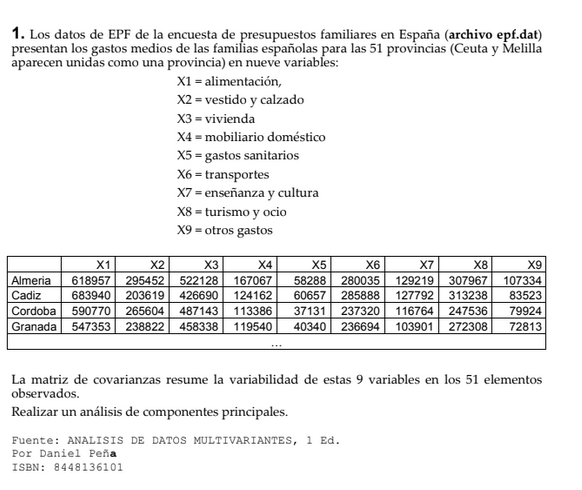

In [1]:
import pandas as pd

In [2]:
#importamos archivo aclarando la hoja que necesitamos dentro del .xls
df = pd.read_excel('Datos ACP.xls', sheet_name='1-epf')
df.head()

,Prov,X1,X2,X3,X4,X5,X6,X7,X8,X9
0,Almeria,618957,295452,522128,167067,58288,280035,129219,307967,107334
1,Cadiz,683940,203619,426690,124162,60657,285888,127792,313238,83523
2,Cordoba,590770,265604,487143,113386,37131,237320,116764,247536,79924
3,Granada,547353,238822,458338,119540,40340,236694,103901,272308,72813
4,Huelva,649225,245722,570631,99250,61953,253286,123244,238880,83070


In [3]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,600781.235294,232042.764706,499955.450980,129687.764706,55103.843137,278111.960784,125310.372549,294558.411765,102224.862745
std,66004.472984,37922.052591,107437.965065,26666.273168,16702.169516,60014.128466,40173.343965,60612.323006,23548.795855
min,430442.000000,167814.000000,332662.000000,78217.000000,24476.000000,136992.000000,57607.000000,189811.000000,54442.000000
25%,547131.000000,201655.000000,417690.500000,113550.000000,42610.000000,235941.000000,97602.500000,244665.500000,84018.500000
50%,598669.000000,228072.000000,487651.000000,129768.000000,54684.000000,280023.000000,118269.000000,291708.000000,100255.000000
75%,646183.000000,256498.000000,553526.000000,143317.000000,63086.500000,315770.500000,145830.500000,323238.500000,117850.500000
max,736441.000000,324877.000000,864553.000000,221954.000000,97595.000000,415313.000000,239187.000000,440275.000000,156493.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Prov    51 non-null     object
 1   X1      51 non-null     int64 
 2   X2      51 non-null     int64 
 3   X3      51 non-null     int64 
 4   X4      51 non-null     int64 
 5   X5      51 non-null     int64 
 6   X6      51 non-null     int64 
 7   X7      51 non-null     int64 
 8   X8      51 non-null     int64 
 9   X9      51 non-null     int64 
dtypes: int64(9), object(1)
memory usage: 4.1+ KB


Tenemos 9 variables, 51 filas y cero nulos.

In [ ]:
#Valido si mis variables estan correladas
df.drop(columns = "Prov").corr()

,X1,X2,X3,X4,X5,X6,X7,X8,X9
X1,1.000000,0.531518,0.475465,0.516663,0.474304,0.527562,0.588740,0.438100,0.483185
X2,0.531518,1.000000,0.549165,0.633368,0.505311,0.587492,0.545900,0.462609,0.532391
X3,0.475465,0.549165,1.000000,0.698919,0.670386,0.691357,0.833380,0.810211,0.541736
X4,0.516663,0.633368,0.698919,1.000000,0.674083,0.727260,0.755607,0.756134,0.635272
X5,0.474304,0.505311,0.670386,0.674083,1.000000,0.729751,0.812127,0.705834,0.590650
X6,0.527562,0.587492,0.691357,0.727260,0.729751,1.000000,0.744703,0.726837,0.713231
X7,0.588740,0.545900,0.833380,0.755607,0.812127,0.744703,1.000000,0.844992,0.562389
X8,0.438100,0.462609,0.810211,0.756134,0.705834,0.726837,0.844992,1.000000,0.582652
X9,0.483185,0.532391,0.541736,0.635272,0.590650,0.713231,0.562389,0.582652,1.000000


Vemos que aparecen numeros altos por lo que podemos avanzar.

In [ ]:
# Estandarizamos los datos

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop(columns = "Prov"))

provincias = df["Prov"]
pd.DataFrame(df_scaled, columns=['X1', 'X2','X3', 'X4','X5', 'X6','X7', 'X8','X9'])

,X1,X2,X3,X4,X5,X6,X7,X8,X9
0,0.278112,1.688732,0.208429,1.415690,0.192540,0.032362,0.098262,0.223420,0.219118
1,1.272432,-0.756989,-0.688718,-0.209281,0.335790,0.130859,0.062388,0.311248,-0.802077
2,-0.153184,0.893812,-0.120441,-0.617408,-1.086786,-0.686469,-0.214854,-0.783509,-0.956430
3,-0.817518,0.180546,-0.391217,-0.384333,-0.892743,-0.697004,-0.538228,-0.370747,-1.261403
4,0.741250,0.364309,0.664372,-1.152791,0.414156,-0.417785,-0.051948,-0.927739,-0.821505
5,-0.681995,-1.298264,-1.572611,-1.640831,-1.085032,-2.374844,-1.702050,-1.745350,-1.926246
6,0.260072,-0.817471,0.077990,-0.328659,0.508789,-0.355738,0.076064,0.484438,-0.353988
7,0.318094,-0.636159,0.464785,0.292394,-0.604854,0.334687,-0.177019,0.232701,-0.759576
8,-0.362245,0.459866,-0.818283,-0.822305,-0.937369,0.962964,-0.873945,-1.121257,-0.434102
9,-0.849881,-0.859018,-1.466791,-0.285332,-0.775375,-0.905813,-0.880381,-0.946618,-1.041604


In [ ]:
# importamos el modulo para aplicar PCA de sklearn

from sklearn.decomposition import PCA


# Creamos una instancia del modelo PCA con todas las componentes principales.
# van a ser 9 porque el minimo entre la cantidad de filas (51) y cantidad de columnas (9) es 9.
pca = PCA(n_components=9)

# Ajustamos el modelo a los datos.
pca.fit(df_scaled)

# Transformamos los datos.
df_pca = pca.transform(df_scaled)

# Convertimos los datos transformados en un DataFrame de Pandas.
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2','PC3', 'PC4','PC5', 'PC6','PC7', 'PC8','PC9'])

# Mostramos las primeras filas del DataFrame.
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,1.393929,0.909147,0.155707,1.310618,-0.021249,0.712855,-0.287458,-0.037086,-0.135339
1,-0.141630,0.133405,-1.189269,-1.086786,0.320966,0.571669,0.466884,0.460750,-0.301341
2,-1.307663,0.764720,-0.618917,1.184539,-0.105556,-0.449228,0.097373,0.038849,0.374573
3,-1.710271,-0.127165,-0.329999,1.078040,-0.061993,0.079969,0.222088,0.172529,0.034416
4,-0.476866,0.540428,-1.246502,0.078303,0.781985,-1.136769,-0.143817,-0.523967,-0.241860


In [ ]:
#vemos filas y columnas
df_pca.shape

(51, 9)

Podemos ver que nuestro dataframe ahora está formado por nuevas variables (CP) con la misma cantidad de filas que los datos originales.

In [ ]:
# Obtenemos el porcentaje de varianza explicada por cada componente principal.
pca.explained_variance_ratio_

# Podemos ver que la primer componente principal explica el 73% de la varianza total, la segunda el 11,6% ...

array([0.67636952, 0.08635654, 0.06185209, 0.05323828, 0.03863168,
       0.03048408, 0.02523606, 0.01703272, 0.01079902])

## **Descripción del modelo ACP: autovectores  y autovalores**

Describimos nuestro modelo obtenido mediante:

-Autovectores de cada CP: son los coeficientes que indican la combinación lineal con las variables originales.

-Autovalores (eigenvalues) de cada CP: indican la varianza que concentra de cada CP.

In [ ]:
import numpy as np
loadings = pca.components_.T  # Transponer para alinear con las variables originales en las filas

features = ['X1', 'X2', 'X3','X4', 'X5', 'X6','X7', 'X8', 'X9', ]

# Crear el DataFrame de cargas
loadings_df = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(loadings.shape[1])], index=features)

loadings_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
X1,0.269571,0.581577,-0.580000,-0.451876,-0.132794,0.051802,0.019534,0.012905,-0.166261
X2,0.288540,0.535195,0.062557,0.702020,0.199903,-0.179110,-0.044257,0.243767,0.011951
X3,0.347630,-0.274192,-0.211072,0.223297,-0.307350,-0.518969,-0.088244,-0.532215,-0.233939
X4,0.352874,-0.002138,0.099333,0.230525,-0.210644,0.800975,-0.057043,-0.350260,-0.024485
X5,0.341089,-0.199768,0.012788,-0.187732,0.786893,0.048665,-0.269446,-0.070030,-0.330560
X6,0.355571,0.007846,0.274582,-0.150499,0.114841,-0.089529,0.864264,-0.079713,0.030855
X7,0.370518,-0.229288,-0.293511,-0.039205,0.100947,-0.033905,-0.102658,0.085913,0.832585
X8,0.352164,-0.389952,-0.058784,0.021279,-0.316013,0.066797,0.007467,0.718180,-0.315983
X9,0.307626,0.235680,0.663404,-0.374285,-0.247237,-0.195835,-0.395565,0.007401,0.116714


Esta matriz indica la contribución de cada variable original al componente principal correspondiente.  


*      **Magnitud de los valores** : Una carga alta (en valor absoluto) significa que la variable correspondiente tiene una fuerte influencia sobre el componente principal. Una carga cercana a cero significa que la variable tiene poca o ninguna influencia sobre ese componente.

     

*   **Signo de los valores:** Una carga positiva indica que la variable contribuye positivamente al componente principal, es decir, que la variable y el componente aumentan juntos. Una carga negativa indica que la variable contribuye negativamente, es decir, que la variable aumenta mientras el componente disminuye, o viceversa.

Por ejemplo para Almeria que era nuestro primer ejemplo en el dataset original, el valor en la **PC1 es 1.393929**  

In [ ]:
df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,1.393929,0.909147,0.155707,1.310618,-0.021249,0.712855,-0.287458,-0.037086,-0.135339
1,-0.141630,0.133405,-1.189269,-1.086786,0.320966,0.571669,0.466884,0.460750,-0.301341
2,-1.307663,0.764720,-0.618917,1.184539,-0.105556,-0.449228,0.097373,0.038849,0.374573
3,-1.710271,-0.127165,-0.329999,1.078040,-0.061993,0.079969,0.222088,0.172529,0.034416
4,-0.476866,0.540428,-1.246502,0.078303,0.781985,-1.136769,-0.143817,-0.523967,-0.241860
5,-4.736513,0.158253,-0.858391,-0.020979,0.389452,0.177240,-0.559976,-0.062260,-0.299083
6,-0.117689,-0.701143,-0.627901,-0.651910,0.148927,0.011880,-0.255584,0.222247,-0.373429
7,-0.137666,-0.389253,-0.674813,-0.059776,-0.714984,0.234309,0.749279,-0.338778,-0.275679
8,-1.369134,0.991693,0.616768,0.318175,0.311159,-0.427198,1.429573,-0.063730,0.192855
9,-2.654090,-0.077922,0.084855,0.073803,0.205694,0.856473,0.088520,0.023538,0.154075



Resulta de hacer:  
Valor en PC1= c1*X1 + c2 * X2 + .... c9 * X9


0.269571 x 0.2781118+0.288540 x 1.68873213+0.347630 x 0.2084289+0.352874⋅1 x 41569003+0.341089 x 0.1925403+0.355571 x 0.03236195+0.370518 x 0.09826218+0.352164 x 0.22342008+0.307626⋅0 x 0.21911845 = 1.39


In [ ]:
# CALCULO DE LOS AUTOVALORES O EIGENVALUES (VARIANZA DE CADA COMPONENTE)
df_varianza = pd.DataFrame(data={'Componente': range(1, 10), 'Varianza': pca.explained_variance_})
df_varianza

,Componente,Varianza
0,1,6.209072
1,2,0.792753
2,3,0.567802
3,4,0.488727
4,5,0.354639
5,6,0.279844
6,7,0.231667
7,8,0.156360
8,9,0.099135


In [ ]:
# VARIANZA DE CADA COMPONENTE PORCENTUALMENTE: VAR(CPi)/ VARIANZA TOTAL
df_varianza_ratio = pd.DataFrame(data={'Componente': range(1, 10), '% Varianza explicada': pca.explained_variance_ratio_})
df_varianza_ratio

,Componente,% Varianza explicada
0,1,0.676370
1,2,0.086357
2,3,0.061852
3,4,0.053238
4,5,0.038632
5,6,0.030484
6,7,0.025236
7,8,0.017033
8,9,0.010799


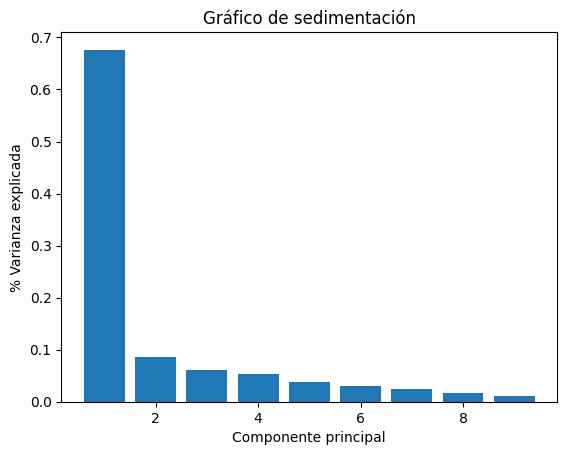

In [ ]:
import matplotlib.pyplot as plt

# Creamos un DataFrame con la varianza explicada por cada componente principal.
df_varianza = pd.DataFrame(data={'Componente': range(1, 10), 'Varianza explicada': pca.explained_variance_ratio_})

# Creamos un gráfico de barras.
plt.bar(df_varianza['Componente'], df_varianza['Varianza explicada'])

# Añadimos etiquetas y título al gráfico.
plt.xlabel('Componente principal')
plt.ylabel('% Varianza explicada')
plt.title('Gráfico de sedimentación')

# Mostramos el gráfico.
plt.show()


## **Reducción de dimensionalidad**
A partir de las varianzas de cada componente, podemos ver que con 2 CP conservamos el 75% de la variabilidad original de los datos. Esto nos permitirá representar las provincias en 2 dimensiones!

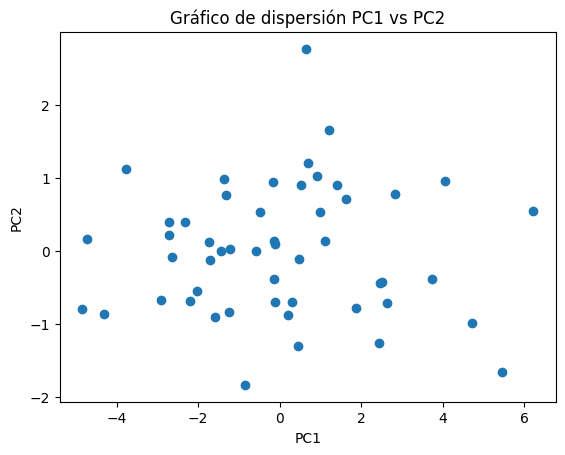

In [ ]:
# Creamos un DataFrame con las dos primeras componentes principales.
df_pca_2 = df_pca[['PC1', 'PC2']]

# Creamos un gráfico de dispersión.
plt.scatter(df_pca_2['PC1'], df_pca_2['PC2'])

# Añadimos etiquetas y título al gráfico.
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Gráfico de dispersión PC1 vs PC2')

# Mostramos el gráfico.
plt.show()


In [ ]:
df_pca_2["prov"] = provincias

<ipython-input-22-255df5b8d668>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pca_2["prov"] = provincias


In [ ]:
#Ahora lo hacemos con plotly para poder ver mejor que provincia es cada punto
import plotly.express as px

fig = px.scatter(df_pca_2, x="PC1", y="PC2", hover_data=["prov"])

fig.update_layout(
    title="Gráfico de dispersión PC1 vs PC2",
    xaxis_title="PC1",
    yaxis_title="PC2",
)

fig.update_traces(marker_size=10)

fig.show()
